ACCIDENT HOTSPOT PREDICTION - EDA

First 5 rows:
   accident_id        city        state   latitude  longitude        date  \
0            0        Pune  Maharashtra  18.680827  73.930388  2023-10-22   
1            1      Mumbai  Maharashtra  18.817732  72.790846  2023-05-21   
2            2      Mumbai  Maharashtra  19.096889  72.819424  2024-07-10   
3            3  Chandigarh       Punjab  30.787805  76.847507  2025-03-30   
4            4     Chennai   Tamil Nadu  12.965155  80.283313  2024-01-25   

    time  hour day_of_week  is_weekend  ... visibility  temperature  \
0   5:00     5      Sunday           1  ...        low           32   
1   4:00     4      Sunday           1  ...       high           34   
2  13:00    13   Wednesday           0  ...        low           21   
3  11:00    11      Sunday           1  ...        low           30   
4  16:00    16    Thursday           0  ...       high           24   

   traffic_density        cause accident_severity  vehicles_i

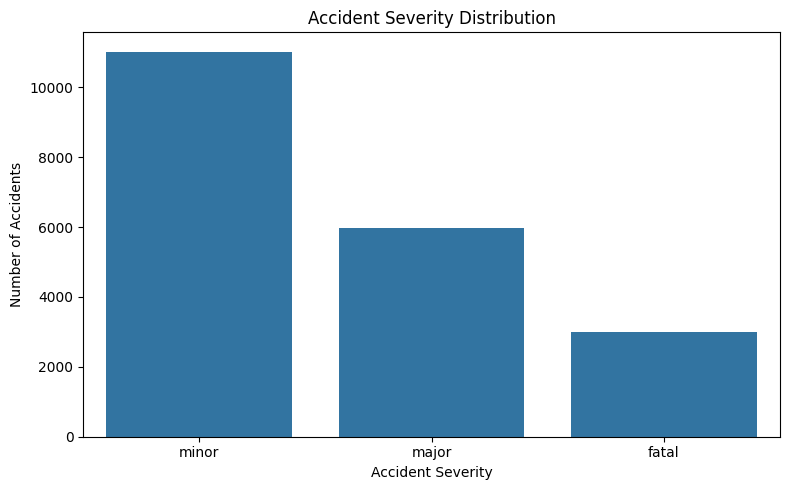

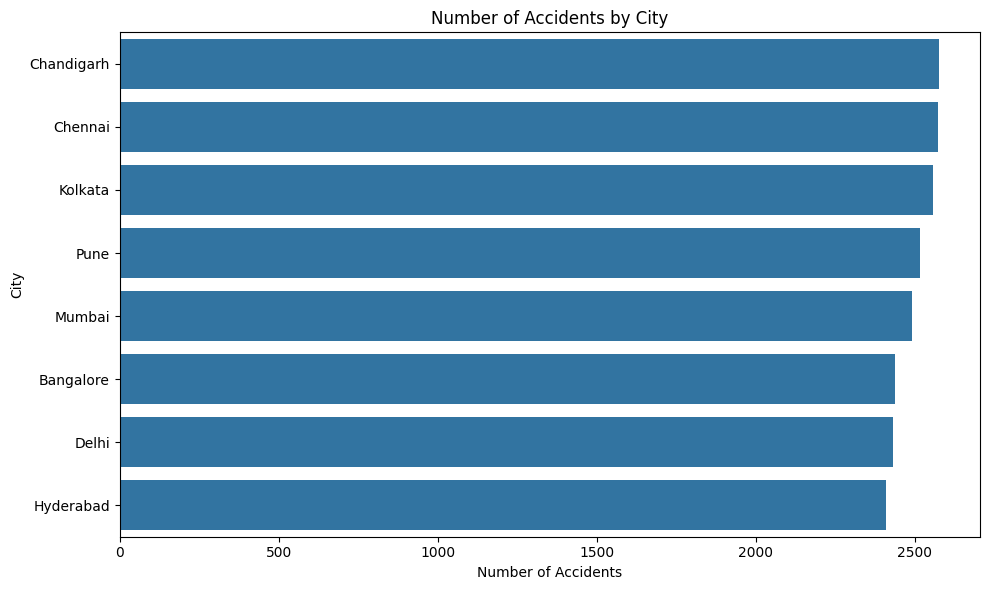

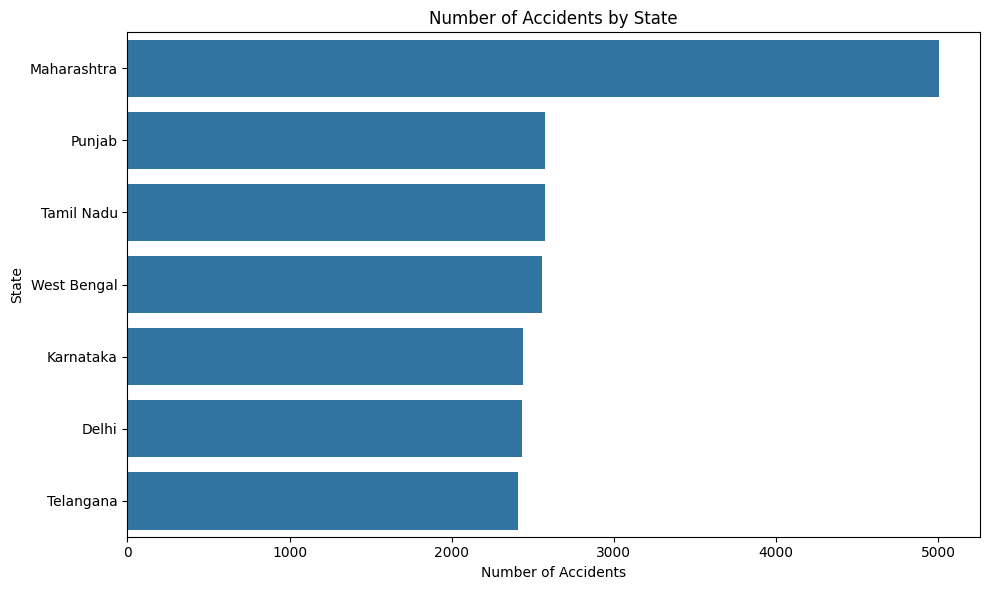

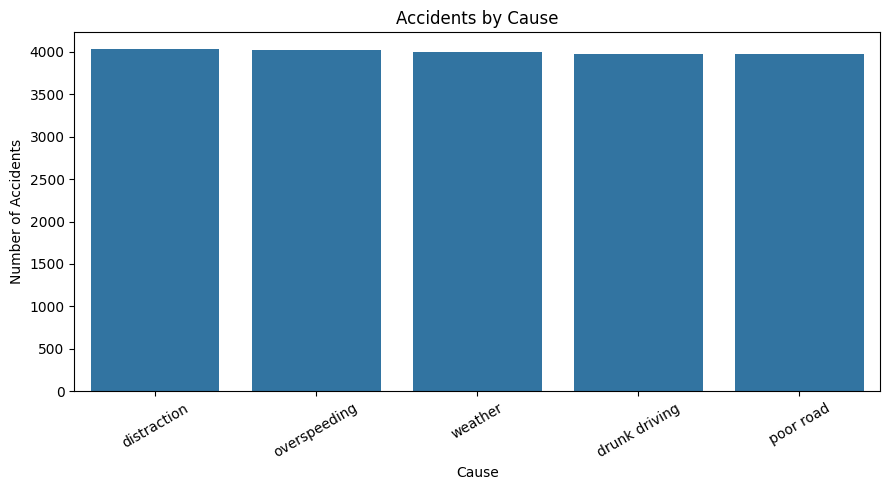

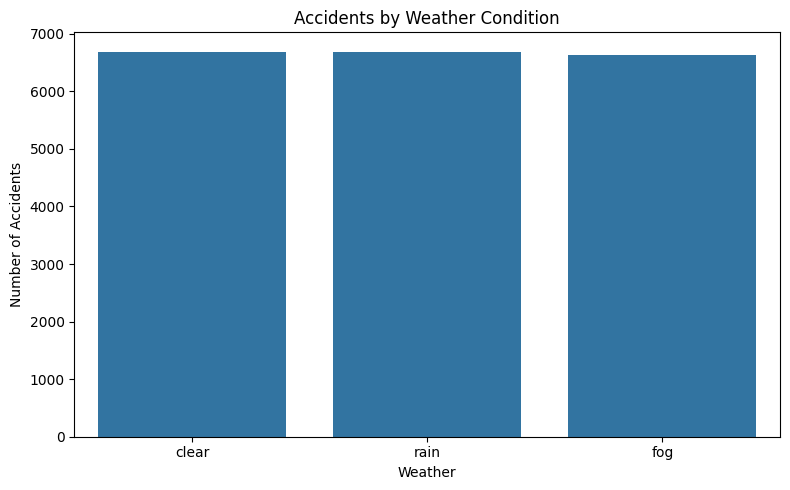

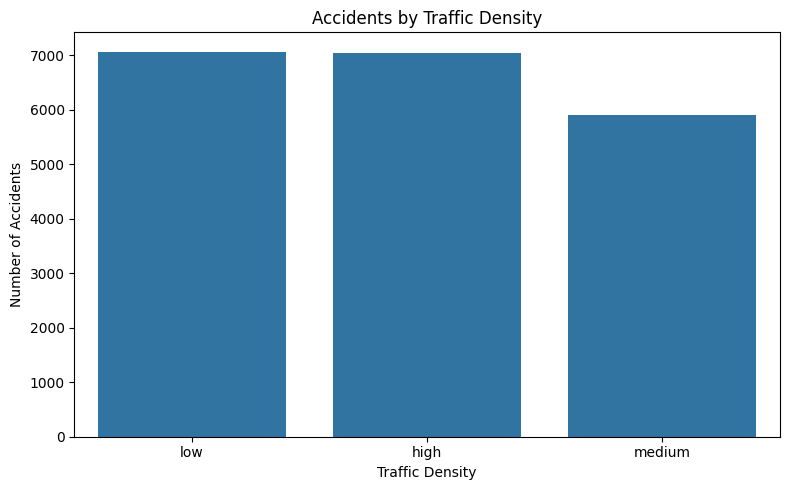

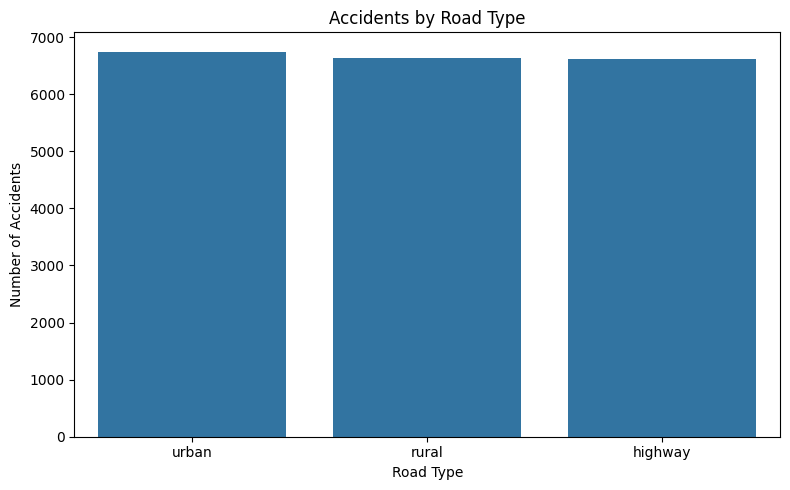

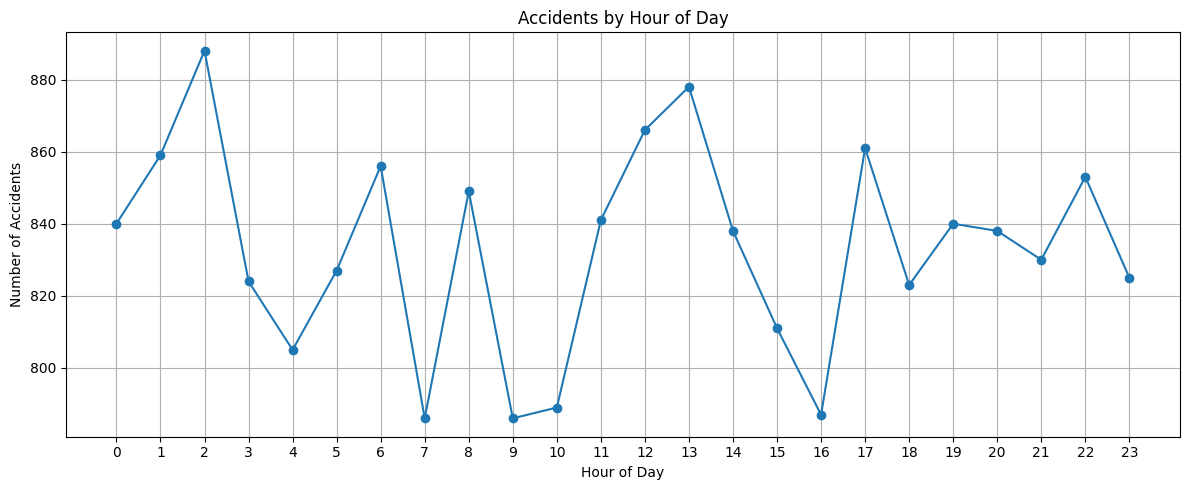

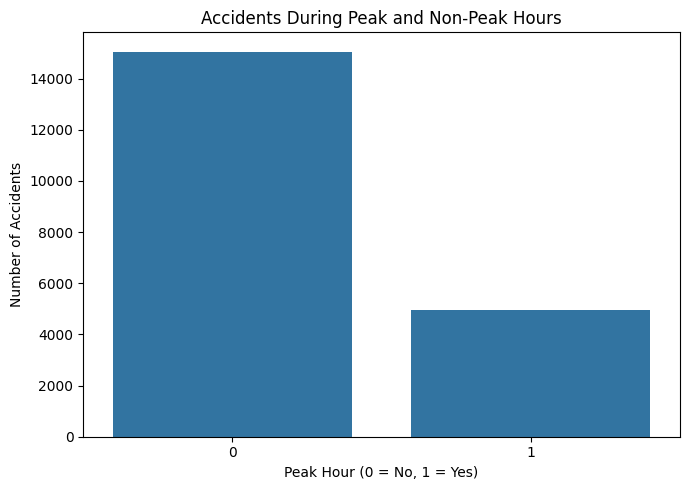

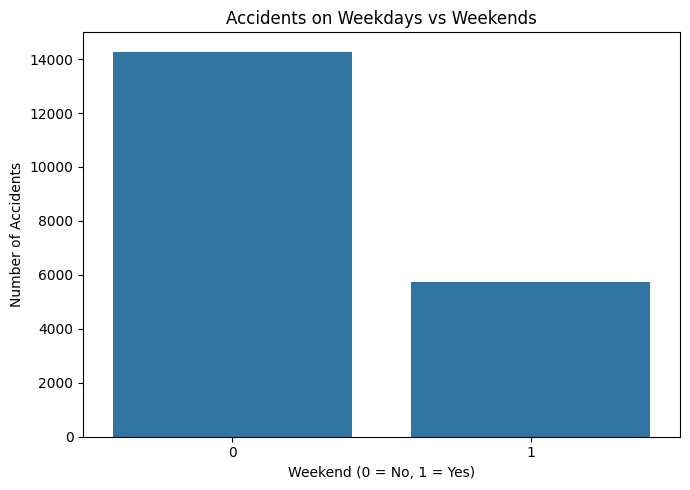

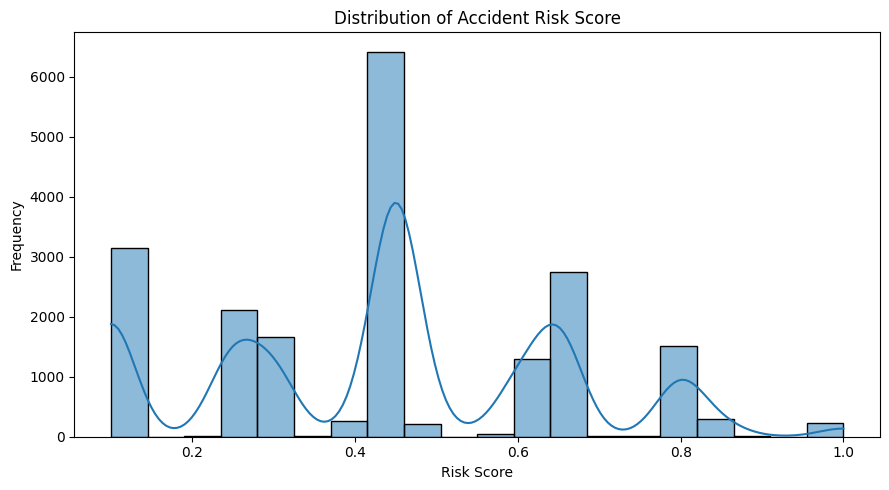


RISK CATEGORY DISTRIBUTION
risk_category
Medium    8254
Low       6936
High      4810
Name: count, dtype: int64


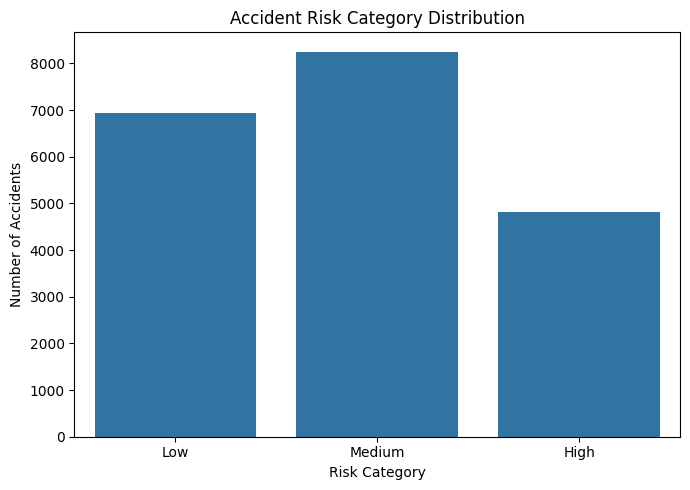

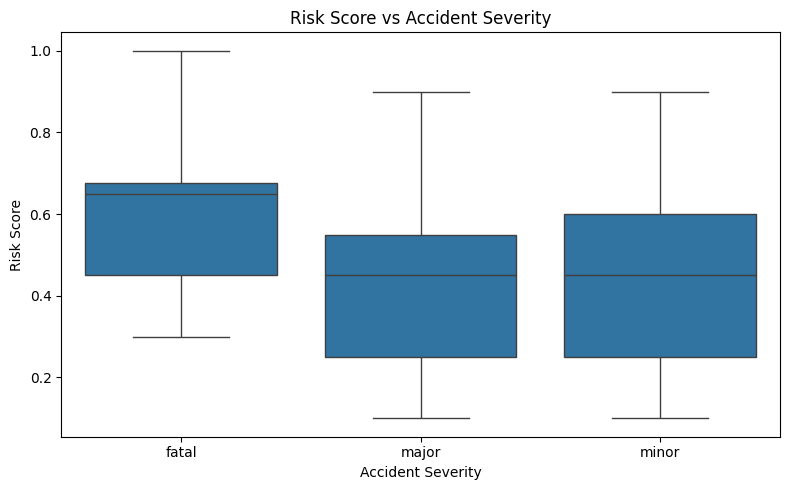

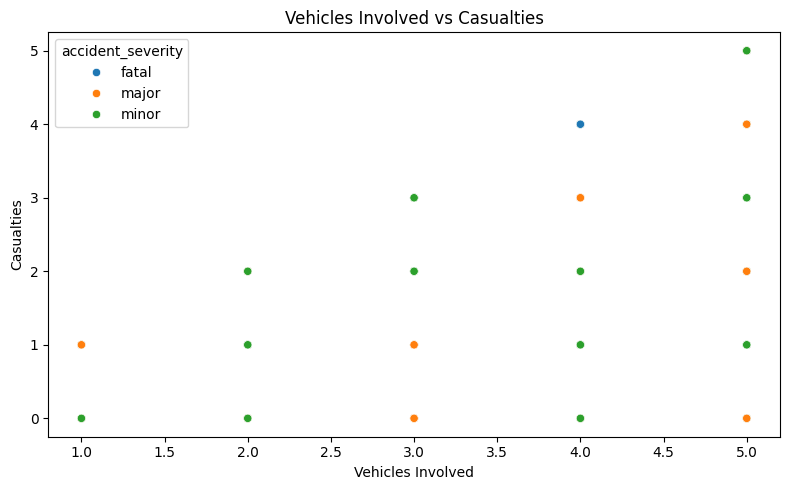

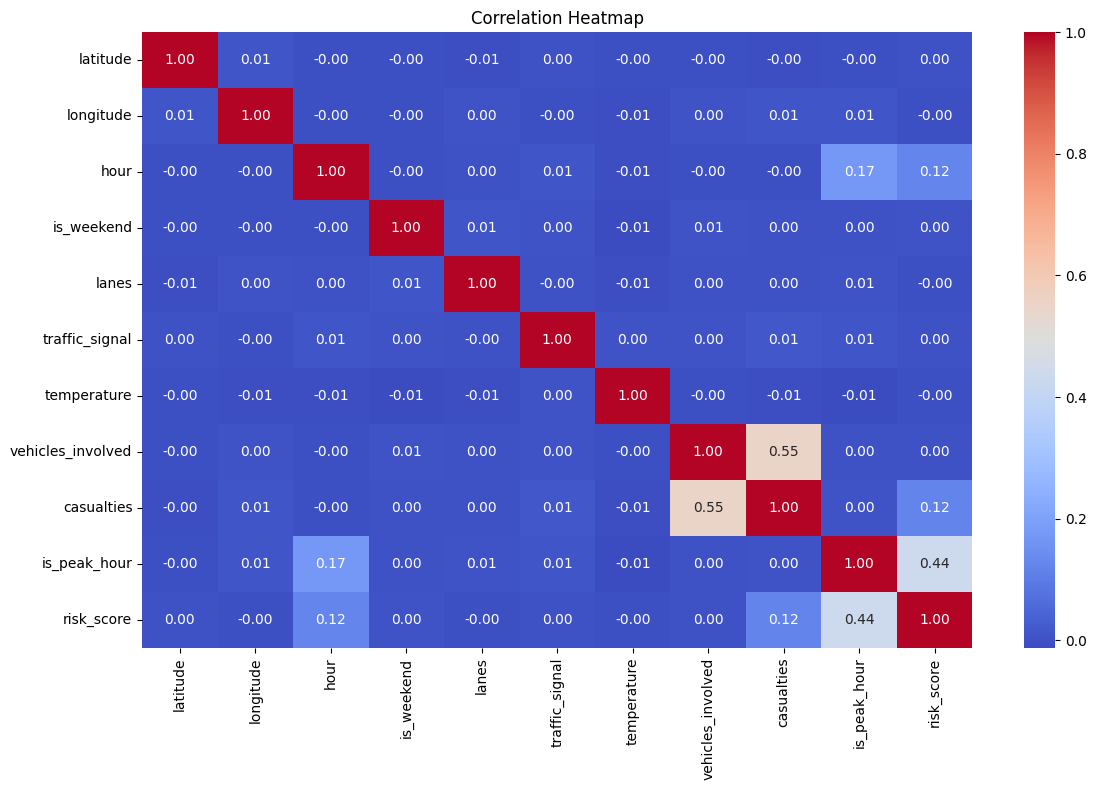

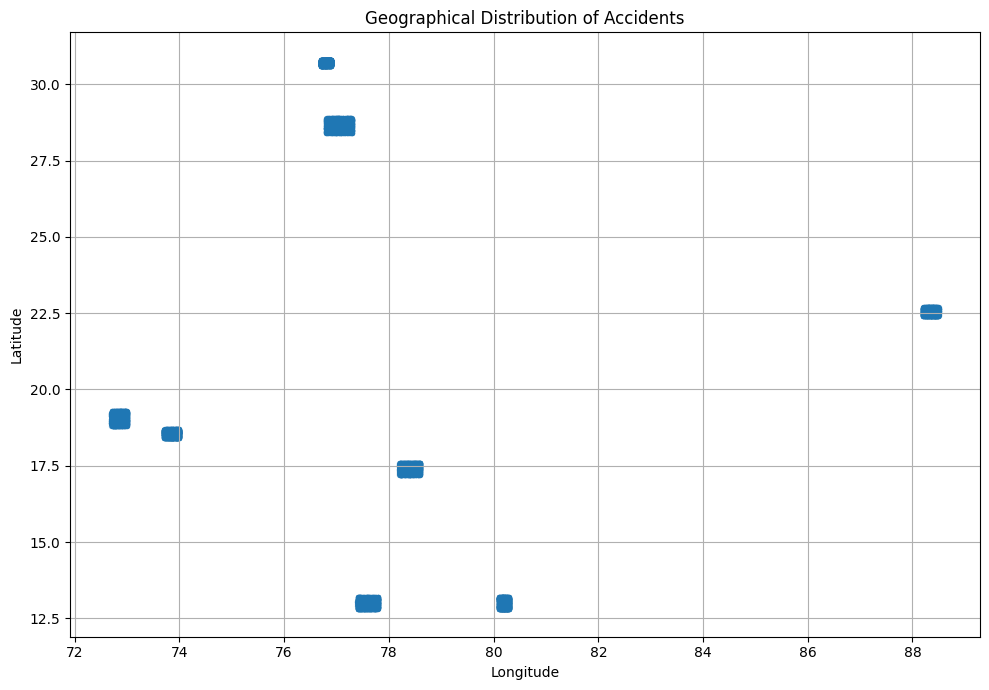

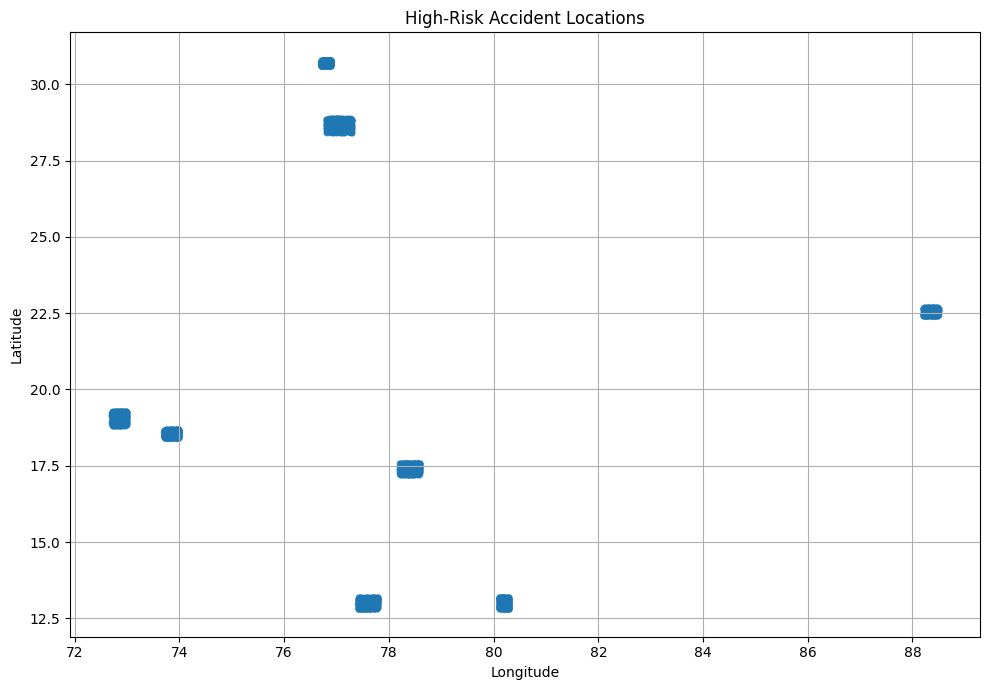

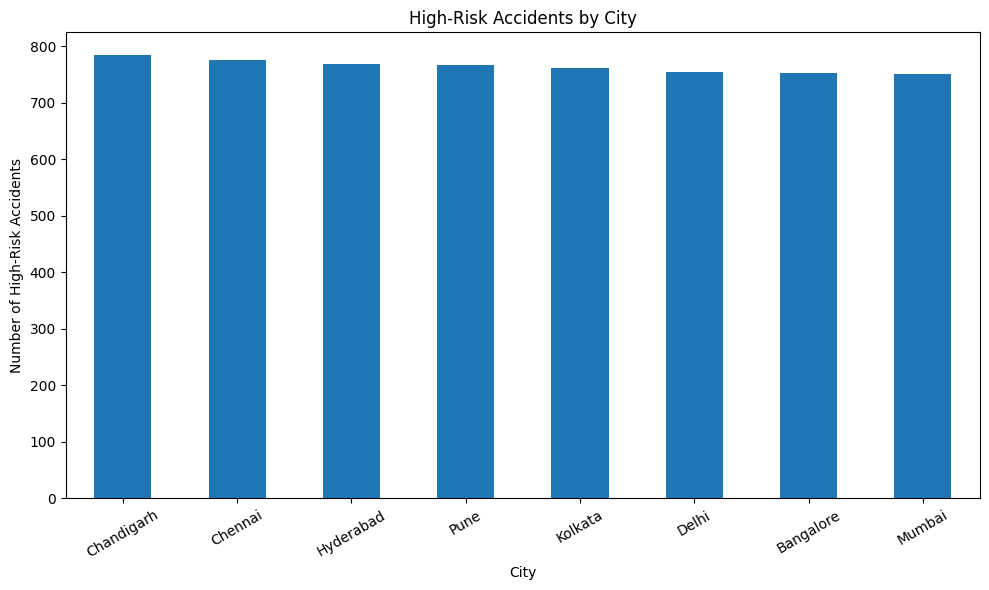

<Figure size 900x600 with 0 Axes>

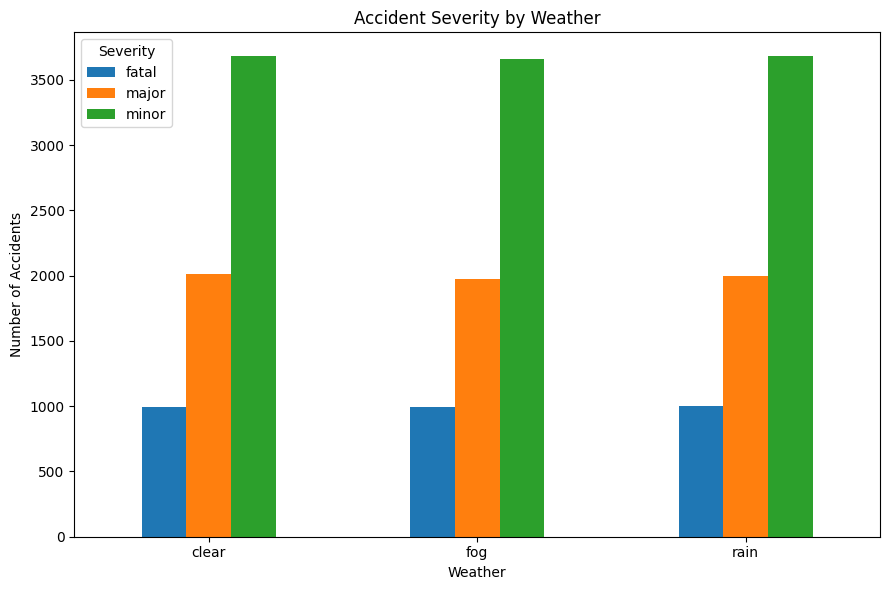

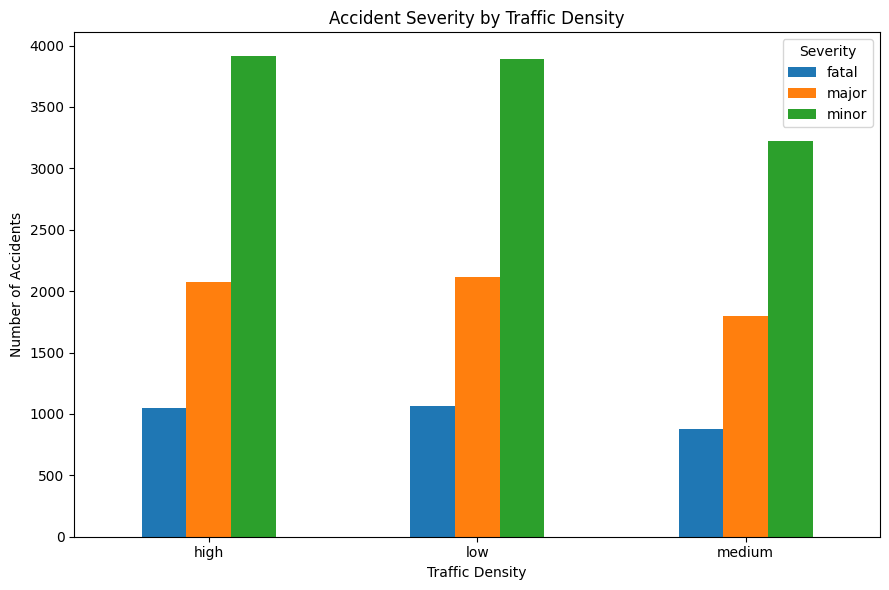


FINAL EDA SUMMARY

Total Accident Records: 20000

Total Cities: 8
Total States: 7

Most Common Accident Severity:
accident_severity
minor    11025
Name: count, dtype: int64

Most Common Accident Cause:
cause
distraction    4026
Name: count, dtype: int64

City with Most Accidents:
city
Chandigarh    2577
Name: count, dtype: int64

Most Common Weather Condition:
weather
clear    6690
Name: count, dtype: int64

Most Common Road Type:
road_type
urban    6745
Name: count, dtype: int64

Highest Risk Score:
1.0

Average Risk Score:
0.43758500000000006

High-Risk Accident Records:
6114

EDA COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# ACCIDENT HOTSPOT PREDICTION
# EDA - Exploratory Data Analysis
# Dataset: Indian Road Accident Dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

df = pd.read_csv("/content/archive (3).zip")

print("=" * 60)
print("ACCIDENT HOTSPOT PREDICTION - EDA")
print("=" * 60)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])


# ------------------------------------------------------------
# 2. DATASET INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(df.info())

print("\nStatistical Summary:")
print(df.describe())


# ------------------------------------------------------------
# 3. CHECK DUPLICATES
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DUPLICATE ANALYSIS")
print("=" * 60)

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")


# ------------------------------------------------------------
# 4. MISSING VALUE ANALYSIS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

missing = df.isnull().sum()

print(missing)

print("\nColumns having missing values:")
print(missing[missing > 0])


# Fill missing festival values
if 'festival' in df.columns:
    df['festival'] = df['festival'].fillna('No Festival')


# ------------------------------------------------------------
# 5. DATA TYPES
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)

print(df.dtypes)


# ------------------------------------------------------------
# 6. ACCIDENT SEVERITY DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='accident_severity',
    order=df['accident_severity'].value_counts().index
)

plt.title("Accident Severity Distribution")
plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. ACCIDENTS BY CITY
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

city_order = df['city'].value_counts().index

sns.countplot(
    data=df,
    y='city',
    order=city_order
)

plt.title("Number of Accidents by City")
plt.xlabel("Number of Accidents")
plt.ylabel("City")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. ACCIDENTS BY STATE
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

state_order = df['state'].value_counts().index

sns.countplot(
    data=df,
    y='state',
    order=state_order
)

plt.title("Number of Accidents by State")
plt.xlabel("Number of Accidents")
plt.ylabel("State")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. ACCIDENTS BY CAUSE
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

cause_order = df['cause'].value_counts().index

sns.countplot(
    data=df,
    x='cause',
    order=cause_order
)

plt.title("Accidents by Cause")
plt.xlabel("Cause")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. ACCIDENTS BY WEATHER
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='weather',
    order=df['weather'].value_counts().index
)

plt.title("Accidents by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. ACCIDENTS BY TRAFFIC DENSITY
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='traffic_density',
    order=df['traffic_density'].value_counts().index
)

plt.title("Accidents by Traffic Density")
plt.xlabel("Traffic Density")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 12. ACCIDENTS BY ROAD TYPE
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='road_type',
    order=df['road_type'].value_counts().index
)

plt.title("Accidents by Road Type")
plt.xlabel("Road Type")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 13. ACCIDENTS BY HOUR
# ------------------------------------------------------------

hour_counts = df['hour'].value_counts().sort_index()

plt.figure(figsize=(12, 5))

plt.plot(
    hour_counts.index,
    hour_counts.values,
    marker='o'
)

plt.title("Accidents by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.xticks(range(24))
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 14. PEAK HOUR ANALYSIS
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='is_peak_hour'
)

plt.title("Accidents During Peak and Non-Peak Hours")
plt.xlabel("Peak Hour (0 = No, 1 = Yes)")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 15. WEEKEND ANALYSIS
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='is_weekend'
)

plt.title("Accidents on Weekdays vs Weekends")
plt.xlabel("Weekend (0 = No, 1 = Yes)")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 16. RISK SCORE DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x='risk_score',
    bins=20,
    kde=True
)

plt.title("Distribution of Accident Risk Score")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 17. CREATE RISK CATEGORIES
# ------------------------------------------------------------

df['risk_category'] = pd.cut(
    df['risk_score'],
    bins=[0, 0.3, 0.6, 1],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

print("\n" + "=" * 60)
print("RISK CATEGORY DISTRIBUTION")
print("=" * 60)

print(df['risk_category'].value_counts())


# ------------------------------------------------------------
# 18. RISK CATEGORY GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='risk_category',
    order=['Low', 'Medium', 'High']
)

plt.title("Accident Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 19. RISK SCORE VS ACCIDENT SEVERITY
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='accident_severity',
    y='risk_score'
)

plt.title("Risk Score vs Accident Severity")
plt.xlabel("Accident Severity")
plt.ylabel("Risk Score")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 20. VEHICLES INVOLVED VS CASUALTIES
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='vehicles_involved',
    y='casualties',
    hue='accident_severity'
)

plt.title("Vehicles Involved vs Casualties")
plt.xlabel("Vehicles Involved")
plt.ylabel("Casualties")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 21. NUMERICAL CORRELATION
# ------------------------------------------------------------

numeric_cols = [
    'latitude',
    'longitude',
    'hour',
    'is_weekend',
    'lanes',
    'traffic_signal',
    'temperature',
    'vehicles_involved',
    'casualties',
    'is_peak_hour',
    'risk_score'
]

# Use only columns that actually exist
numeric_cols = [
    col for col in numeric_cols
    if col in df.columns
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 22. GEOGRAPHICAL ACCIDENT DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.scatter(
    df['longitude'],
    df['latitude'],
    s=8,
    alpha=0.5
)

plt.title("Geographical Distribution of Accidents")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 23. HIGH-RISK ACCIDENT LOCATIONS
# ------------------------------------------------------------

high_risk = df[df['risk_score'] >= 0.6]

plt.figure(figsize=(10, 7))

plt.scatter(
    high_risk['longitude'],
    high_risk['latitude'],
    s=10,
    alpha=0.6
)

plt.title("High-Risk Accident Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 24. HIGH-RISK ACCIDENTS BY CITY
# ------------------------------------------------------------

high_risk_city = (
    high_risk['city']
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

high_risk_city.plot(kind='bar')

plt.title("High-Risk Accidents by City")
plt.xlabel("City")
plt.ylabel("Number of High-Risk Accidents")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 25. SEVERITY VS WEATHER
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

severity_weather = pd.crosstab(
    df['weather'],
    df['accident_severity']
)

severity_weather.plot(
    kind='bar',
    figsize=(9, 6)
)

plt.title("Accident Severity by Weather")
plt.xlabel("Weather")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)
plt.legend(title="Severity")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 26. SEVERITY VS TRAFFIC DENSITY
# ------------------------------------------------------------

severity_traffic = pd.crosstab(
    df['traffic_density'],
    df['accident_severity']
)

severity_traffic.plot(
    kind='bar',
    figsize=(9, 6)
)

plt.title("Accident Severity by Traffic Density")
plt.xlabel("Traffic Density")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)
plt.legend(title="Severity")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 27. FINAL EDA SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL EDA SUMMARY")
print("=" * 60)

print("\nTotal Accident Records:", len(df))

print("\nTotal Cities:", df['city'].nunique())

print("Total States:", df['state'].nunique())

print("\nMost Common Accident Severity:")
print(df['accident_severity'].value_counts().head(1))

print("\nMost Common Accident Cause:")
print(df['cause'].value_counts().head(1))

print("\nCity with Most Accidents:")
print(df['city'].value_counts().head(1))

print("\nMost Common Weather Condition:")
print(df['weather'].value_counts().head(1))

print("\nMost Common Road Type:")
print(df['road_type'].value_counts().head(1))

print("\nHighest Risk Score:")
print(df['risk_score'].max())

print("\nAverage Risk Score:")
print(df['risk_score'].mean())

print("\nHigh-Risk Accident Records:")
print(len(high_risk))

print("\n" + "=" * 60)
print("EDA COMPLETED SUCCESSFULLY")
print("=" * 60)